# Marketing Campaigns 
**Course:** Applied Data Science with Python  
**Student Name:** `Brian Gaddy`  
**Date:** `03-16-2026`  

---

## 1. Objective

*Conduct exploratory data analysis and hypothesis testing to enhance your comprehension of the diverse factors influencing customer acquisition. The problem statement does not state the audience but I will infer the information will be for the Sales and Marketing head. This analysis will helps businesses optimize products, pricing, distribution, and promotions for better customer engagement and market performance*

## 2. Data Overview

| Field | Details |
|---|---|
| **Source** | *maketing_data.csv* |
| **Rows** | *2,240* |
| **Columns** | *28* |
| **Date Range** | *7/30/2012 - 6/29/2014* |
| **Key Columns** | *Income, NumDealsPurchases, Country, Complain* |

## 3. Imports

In [1]:
# Import libraries

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import pandas as pd
import numpy as np
from scipy import stats
import datetime

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries loaded ')

Libraries loaded 


## 4. Load Data

In [2]:
# Load your dataset here
df = pd.read_csv("C:\\Users\\brian\\OneDrive\\Desktop\\AI and ML Certificate Program\\Projects\\Market Campaigns\\marketing_data.csv")   # change to read_excel / read_json as needed

print(f'Shape: {df.shape}')
df.head()

Shape: (2240, 28)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,104,379,111,189,218,1,4,4,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,5,64,7,0,37,1,7,3,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,11,59,15,2,30,1,3,2,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,0,1,0,0,0,1,1,0,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,16,24,11,0,34,2,3,1,2,7,1,0,0,0,0,1,0,SP


In [3]:
# Quick structural overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

---
## 5. Data Wrangling

### 5.1 Data Type Fixes

In [4]:
# TODO: Fix any columns with wrong data types

# Remove space from column names
df.columns = df.columns.str.replace(' ', '')

# Convert 'Income' to numeric (remove $ and commas if present)
df['Income'] = df['Income'].replace('[\$,]', '', regex=True).astype(float)

# Convert Dt_Customer to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], errors='coerce')

# Convert Education, Marital_Status, and Country to categorical
cols = ['Education', 'Marital_Status', 'Country']
df[cols] = df[cols].astype('category')

# Convert AcceptedCmp1–5, Response, Complain to boolean
bool_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'Complain']
df[bool_cols] = df[bool_cols].astype(bool)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   category      
 3   Marital_Status       2240 non-null   category      
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

- I converted "Income" to a float and removed the dollar sign and commas where present. 

- I converted "Dt_Customer" to a datetime data type for time-based analysis

- The "Education", "Marital_Status", and "Country" columns were converted to categorical data types.

- "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response", and "Complain" were converted to boolean data types.

### 5.2 Missing Value Check

In [5]:
# Check missing values
missing = df.isna().sum()
missing_pct = (df.isna().sum() / len(df) * 100).round(2)
NotNA = df.notna().sum()
missing_df = pd.DataFrame({'Missing': missing, 'Not Missing': NotNA, 'Missing %': missing_pct})
print(missing_df)

#list records with missing values
missing_records = df[df.isna().any(axis=1)]
print('\n********** Records with Missing values: **********')
print(missing_records)


                     Missing  Not Missing  Missing %
ID                         0         2240       0.00
Year_Birth                 0         2240       0.00
Education                  0         2240       0.00
Marital_Status             0         2240       0.00
Income                    24         2216       1.07
Kidhome                    0         2240       0.00
Teenhome                   0         2240       0.00
Dt_Customer                0         2240       0.00
Recency                    0         2240       0.00
MntWines                   0         2240       0.00
MntFruits                  0         2240       0.00
MntMeatProducts            0         2240       0.00
MntFishProducts            0         2240       0.00
MntSweetProducts           0         2240       0.00
MntGoldProds               0         2240       0.00
NumDealsPurchases          0         2240       0.00
NumWebPurchases            0         2240       0.00
NumCatalogPurchases        0         2240     

In [6]:
# TODO: Treat missing values
# Option A — Drop rows where a critical column is null:
#   df.dropna(subset=['column_name'], inplace=True)

# Option B — Fill numeric columns with median:
#   df['column_name'].fillna(df['column_name'].median(), inplace=True)

# Option C — Fill by group (e.g., fill Income by Education + Marital Status group):

# Fill missing 'Income' values by Education + Marital Status group
df['Income'] = df.groupby(['Education', 'Marital_Status'])['Income'].transform(lambda x: x.fillna(x.median()))

# Check missing values
missing = df.isna().sum()
missing_pct = (df.isna().sum() / len(df) * 100).round(2)
NotNA = df.notna().sum()
missing_df = pd.DataFrame({'Missing': missing, 'Not Missing': NotNA, 'Missing %': missing_pct})
print(missing_df)

#list records with missing values
missing_records = df[df.isna().any(axis=1)]
print('\n********** Records with Missing values: **********\n')
print(missing_records)

                     Missing  Not Missing  Missing %
ID                         0         2240       0.00
Year_Birth                 0         2240       0.00
Education                  0         2240       0.00
Marital_Status             0         2240       0.00
Income                     0         2240       0.00
Kidhome                    0         2240       0.00
Teenhome                   0         2240       0.00
Dt_Customer                0         2240       0.00
Recency                    0         2240       0.00
MntWines                   0         2240       0.00
MntFruits                  0         2240       0.00
MntMeatProducts            0         2240       0.00
MntFishProducts            0         2240       0.00
MntSweetProducts           0         2240       0.00
MntGoldProds               0         2240       0.00
NumDealsPurchases          0         2240       0.00
NumWebPurchases            0         2240       0.00
NumCatalogPurchases        0         2240     

**📝 Note:** *(Explain your choice — why drop vs fill? What risk does each carry for this dataset?)*

Group-based imputation is preferred because it balances data retention and accuracy, while dropping risks losing valuable patterns and global median imputation risks oversimplifying the data. *Note, I had to convert the income data type before I could perform the grouping (Section 5.2). 

### 5.3 Duplicate Records

In [7]:
# Are there any duplicate records?
duplicate_records = df.duplicated()
print(f"Number of duplicate records: {duplicate_records.sum()}")

Number of duplicate records: 0


### 5.4 Feature Engineering

In [8]:
# TODO: Create any derived columns your analysis needs

# Change 2n Cycle to Master, Graduation to Bachelor, and Basic to High School Diploma.
df['Education'] = df['Education'].replace({
    '2n Cycle': "Master",
    'Graduation': "Bachelor",
    'Basic': "High School Diploma"
})

# Clean up marital status column
df['Marital_Status'] = df['Marital_Status'].replace({
    'Married': 'Married',
    'Together': 'Married',
    'Single': 'Single',
    'Divorced': 'Divorced',
    'Widow': 'Widow',
    'Alone': 'Single',
    'Absurd': 'Single',
    'YOLO': 'Single',
    'Unknown': 'Unknown'
})

current_year = datetime.datetime.now().year
df['Age'] = current_year - df['Year_Birth']

# Age groups
bins = [0, 18, 35, 50, 65, np.inf]
labels = ['Kids (0-17)', 'Young Adults (18-34)', 'Adults (35-49)', 'Seniors (50-64)', 'Elderly (65+)']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
#print("\n","*" *30, "Data Frame with Age Groups","*"*30,'\n', df[['Age', 'Age_Group']].head())

# Create variables to represent the total number of children, age, and total spending across all product categories, 
# and the total number of purchases acrross the three channels (web, store, and catalog).
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

df['Age'] = 2026 - df['Year_Birth']

df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts',
                          'MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)

df['Total_Purchases'] = df[['NumWebPurchases','NumStorePurchases','NumCatalogPurchases']].sum(axis=1)

print("Data Frame with new columns:")
df.head()

Data Frame with new columns:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Age,Age_Group,Total_Children,Total_Spending,Total_Purchases
0,1826,1970,Bachelor,Divorced,84835.00,0,0,2014-06-16,0,189,104,379,111,189,218,1,4,4,6,1,False,False,False,False,False,True,False,SP,56,Seniors (50-64),0,1190,14
1,1,1961,Bachelor,Single,57091.00,0,0,2014-06-15,0,464,5,64,7,0,37,1,7,3,7,5,False,False,False,False,True,True,False,CA,65,Elderly (65+),0,577,17
2,10476,1958,Bachelor,Married,67267.00,0,1,2014-05-13,0,134,11,59,15,2,30,1,3,2,5,2,False,False,False,False,False,False,False,US,68,Elderly (65+),1,251,10
3,1386,1967,Bachelor,Married,32474.00,1,1,2014-05-11,0,10,0,1,0,0,0,1,1,0,2,7,False,False,False,False,False,False,False,AUS,59,Seniors (50-64),2,11,3
4,5371,1989,Bachelor,Single,21474.00,1,0,2014-04-08,0,6,16,24,11,0,34,2,3,1,2,7,True,False,False,False,False,True,False,SP,37,Adults (35-49),1,91,6


I cleaned up the Martial_Status column and created variable for total number of children, customer age, total spend across procuct categories, and the total spend across purchasing channels. I also grouped the age category.

### 5.5 GroupBy — Chunking & Aggregation

In [9]:
# TODO: Use GroupBy to aggregate data by a meaningful dimension

# Example:
#   state_summary = df.groupby('State').agg(
#       Total_Sales = ('Sales', 'sum'),
#       Avg_Sales   = ('Sales', 'mean'),
#       Total_Units = ('Unit',  'sum')
#   ).sort_values('Total_Sales', ascending=False)

# marital status and sales analysis
campaign_Marital_Status = df.groupby('Marital_Status').agg(
    Total_Spending = ('Total_Spending', 'sum'),
    Avg_Spending   = ('Total_Spending', 'mean'),
    Total_Purchases = ('Total_Purchases', 'sum'),
    Avg_Purchases   = ('Total_Purchases', 'mean')
).sort_values('Total_Spending', ascending=False)
print("="*27, "Spending and Purchase Summary by Marital Status","="*23,"\n", campaign_Marital_Status)

# Age_group and sales analysis
campaign_Age_Group = df.groupby('Age_Group').agg(
    Ttl_Spending = ('Total_Spending', 'sum'),
    Avg_Spending   = ('Total_Spending', 'mean'),
    Ttl_Purchases = ('Total_Purchases', 'sum'),
    Avg_Purchases   = ('Total_Purchases', 'mean')
).sort_values('Ttl_Spending', ascending=False)
print("\n","=" *27, "Spending and Purchase Summary by Age Group","="*27,'\n',campaign_Age_Group)

# Age_group and sales channel analysis
campaign_Age_Channel = df.groupby('Age_Group').agg(
    Web_Purchases = ('NumWebPurchases', 'sum'),
    Store_Purchases = ('NumStorePurchases', 'sum'),
    Catalog_Purchases = ('NumCatalogPurchases', 'sum')
).sort_values('Age_Group', ascending=False)
print("\n","=" *30, "Sales Channel Summary by Age Group","="*32,'\n',campaign_Age_Channel)

# Sales channels for customers with children vs. without children
campaign_Children_Channel = df.groupby('Total_Children').agg(
    Ttl_Web_Purchases = ('NumWebPurchases', 'sum'),
    Ttl_Store_Purchases = ('NumStorePurchases', 'sum'),
    Ttl_Cat_Purchases = ('NumCatalogPurchases', 'sum')
).sort_values('Total_Children', ascending=False)
print("\n","=" *30, "Sales Channel Summary by Number of Children","="*24,'\n',campaign_Children_Channel)

# Total Purchases per channel
Web_purchases = df['NumWebPurchases'].sum()
Store_purchases = df['NumStorePurchases'].sum()
Catalog_purchases = df['NumCatalogPurchases'].sum()
Total_purchases = Web_purchases + Store_purchases + Catalog_purchases
print('\n',"=" * 30, f'Total Purchases Per Channel:', "="*39, f'\nWeb - {Web_purchases} \nStore - {Store_purchases} \nCatalog - {Catalog_purchases} \nTotal - {Total_purchases}')

# Percentage of Customer Sales at physical stores compared to web and catalog channels.
Pct_Web = Web_purchases/Total_purchases
Pct_Store = Store_purchases/Total_purchases
Pct_Catalog = Catalog_purchases/Total_purchases
print('\n',"=" * 30, f'Percentage of Purchases Per Channel:', "="*31, f'\nWeb - {Pct_Web:.2%} \nStore - {Pct_Store:.2%} \nCatalog - {Pct_Catalog:.2%}')

# Total US sales vs all other countries
campaign_Country = df.groupby('Country').agg(
    Ttl_Sales = ('Total_Spending', 'sum',),
    Avg_Sales   = ('Total_Spending', 'mean'),
    Ttl_Purchases = ('Total_Purchases', 'sum'),
    Avg_Purchases   = ('Total_Purchases', 'mean')
).sort_values('Ttl_Sales', ascending=False)
print('\n',"=" *30, "Sales Summary by Country","="*43,'\n',campaign_Country)

=========================== Spending and Purchase Summary by Marital Status ======================= 
                 Total_Spending  Avg_Spending  Total_Purchases  Avg_Purchases
Marital_Status                                                              
Married                 863318        597.87            18101          12.54
Single                  295115        605.99             5906          12.13
Divorced                141666        610.63             2970          12.80
Widow                    56889        738.82             1106          14.36

 =========================== Spending and Purchase Summary by Age Group =========================== 
                       Ttl_Spending  Avg_Spending  Ttl_Purchases  Avg_Purchases
Age_Group                                                                     
Seniors (50-64)             557259        569.21          11990          12.25
Elderly (65+)               468892        715.87           9300          14.20
Adults (35-49)   

**📝 Note:** *(What does this grouping reveal? Is there a natural chunking dimension in this dataset?)*

This grouping reveals that customer demographics drive meaningful differences in spending and purchasing behavior, particularly across age groups and marital status. For example, Elderly (65+) customers have higher average spending and purchases, while Married customers contribute the highest total spending, indicating both value and volume differences across segments. Channel data shows a consistent preference for store purchases (46%), especially among older groups, suggesting behavior varies not just by who the customer is, but how they shop.

There is a clear natural “chunking” dimension in this dataset: customer segmentation by age group. Age consistently explains differences in spending levels, purchase frequency, and channel preference, making it the strongest candidate for grouping customers in analysis, targeting, and strategy development.

### 5.6 Generate box plots and histograms to gain insights into the distributions and identify outliers

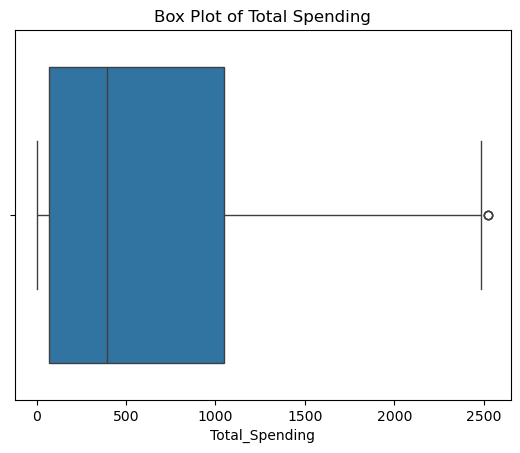

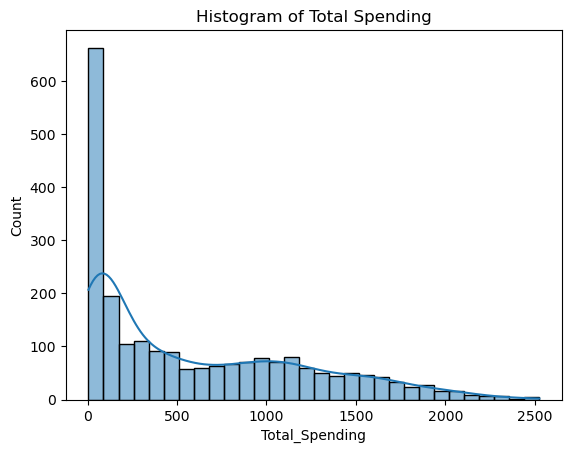

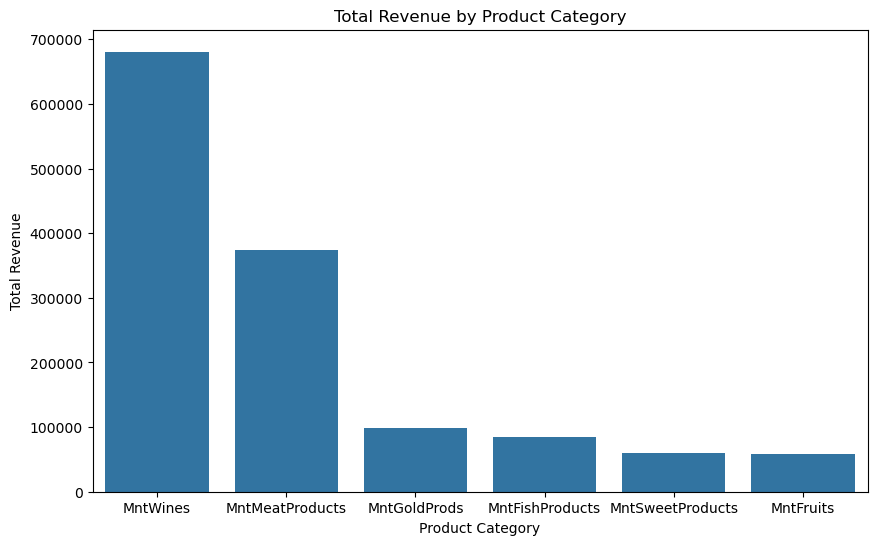

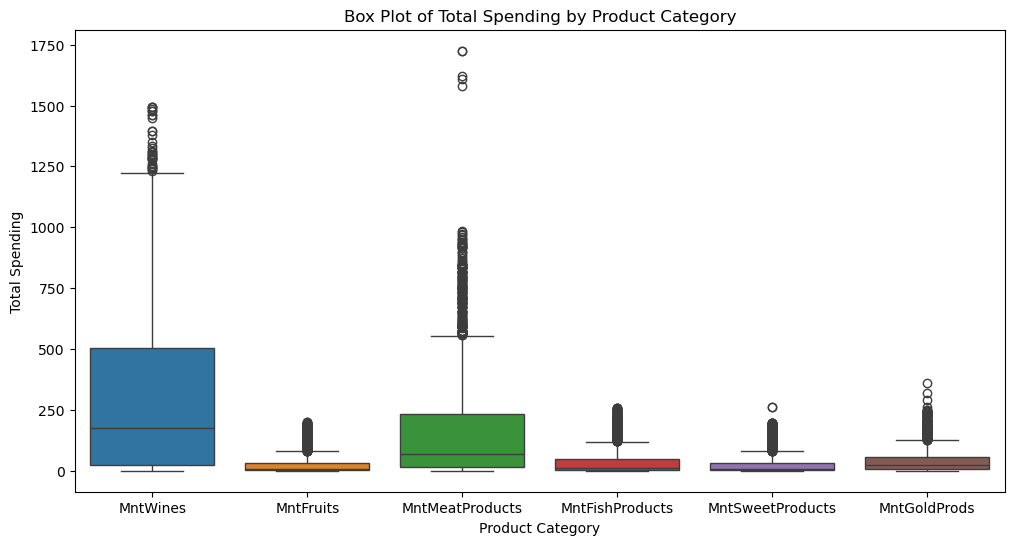

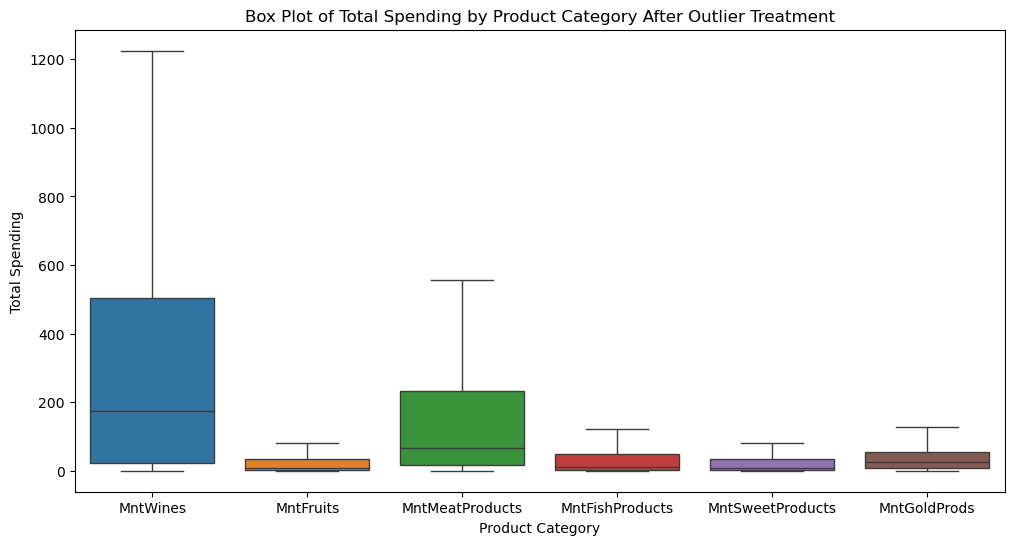

In [ ]:
# Generate box plots and histograms to gain insights into the distributions and identify outliers.

# Implement outlier treatment as needed (e.g., capping, transformation, or removal) based on the insights gained from the visualizations.

# Box plot of total spending
sns.boxplot(x='Total_Spending', data=df)
plt.title('Box Plot of Total Spending')
plt.show()

# Total spending distribution
sns.histplot(df['Total_Spending'], bins=30, kde=True)
plt.title('Histogram of Total Spending')
plt.show()

# Total revenue by product category
mnt_cols = [c for c in df.columns if c.startswith('Mnt')]
product_revenue = df[mnt_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=product_revenue.index, y=product_revenue.values)
plt.title('Total Revenue by Product Category')
plt.ylabel('Total Revenue')
plt.xlabel('Product Category')
plt.show()

# Box plot of total spending by product category
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[mnt_cols])
plt.title('Box Plot of Total Spending by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Spending')
plt.show()

# Outlier treatment using IQR method for each product category
for col in mnt_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

# Box plot of total spending by product category after outlier treatment
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[mnt_cols])
plt.title('Box Plot of Total Spending by Product Category After Outlier Treatment')
plt.xlabel('Product Category')
plt.ylabel('Total Spending')
plt.show()

# explain the observation of the data
# After outlier treatment, the box plots show a more compact distribution of total spending by product category, reducing the impact of extreme values. This helps in better understanding the central tendency and variability of spending across different product categories.

**📝 Insight:** After outlier treatment, the box plots show a more compact distribution of total spending by product category, reducing the impact of extreme values. This helps in better understanding the central tendency and variability of spending across different product categories.

---
## 6. Ordinal and One-hot Encoding
Apply ordinal and one-hot encoding based on the various types of categorical variables. ("Education", "Marital_Status", and "Country")

In [11]:
# Apply ordinal and one-hot encoding based on the various types of categorical variables. ("Education", "Marital_Status", "Age_Group" and "Country"). 
# Keep original data columns.

# Remove any leading/trailing spaces
df['Education'] = df['Education'].str.strip()
df['Marital_Status'] = df['Marital_Status'].str.strip()
df['Country'] = df['Country'].str.strip()
df['Age_Group'] = df['Age_Group'].str.strip()

cols = ['Education', 'Marital_Status', 'Country', 'Age_Group']
df[cols] = df[cols].astype('category')

# Ordinal Encoding (Education)
# Define order
education_order = ['High School Diploma','Bachelor','Master','PhD']

# Initialize encoder
ord_enc = OrdinalEncoder(categories=[education_order])

# Create new encoded column (keep original)
df['Education_Ordinal'] = ord_enc.fit_transform(df[['Education']])

# One-Hot Encoding (Marital_Status, Country, Age_Group)
# Initialize encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform
encoded_cols = ohe.fit_transform(df[['Marital_Status', 'Country', 'Age_Group']])

# Get new column names 
encoded_col_names = ohe.get_feature_names_out(['Marital_Status', 'Country', 'Age_Group'])

# Convert to DataFrame
encoded_df = pd.DataFrame(encoded_cols, columns=encoded_col_names, index=df.index)

# Concatenate with original dataframe
df = pd.concat([df, encoded_df], axis=1)

# Verify Results
print(df.head())


      ID  Year_Birth Education Marital_Status   Income  Kidhome  Teenhome  \
0   1826        1970  Bachelor       Divorced 84835.00        0         0   
1      1        1961  Bachelor         Single 57091.00        0         0   
2  10476        1958  Bachelor        Married 67267.00        0         1   
3   1386        1967  Bachelor        Married 32474.00        1         1   
4   5371        1989  Bachelor         Single 21474.00        1         0   

  Dt_Customer  Recency  MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
0  2014-06-16        0    189.00      81.00           379.00           111.00   
1  2014-06-15        0    464.00       5.00            64.00             7.00   
2  2014-05-13        0    134.00      11.00            59.00            15.00   
3  2014-05-11        0     10.00       0.00             1.00             0.00   
4  2014-04-08        0      6.00      16.00            24.00            11.00   

   MntSweetProducts  MntGoldProds  NumDealsPurchas

In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 50 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ID                              2240 non-null   int64         
 1   Year_Birth                      2240 non-null   int64         
 2   Education                       2240 non-null   category      
 3   Marital_Status                  2240 non-null   category      
 4   Income                          2240 non-null   float64       
 5   Kidhome                         2240 non-null   int64         
 6   Teenhome                        2240 non-null   int64         
 7   Dt_Customer                     2240 non-null   datetime64[ns]
 8   Recency                         2240 non-null   int64         
 9   MntWines                        2240 non-null   float64       
 10  MntFruits                       2240 non-null   float64       
 11  MntM

---
## 7. Heatmap
Generate a heatmap to illustrate the correlation between different pairs of variables. 

<Axes: >

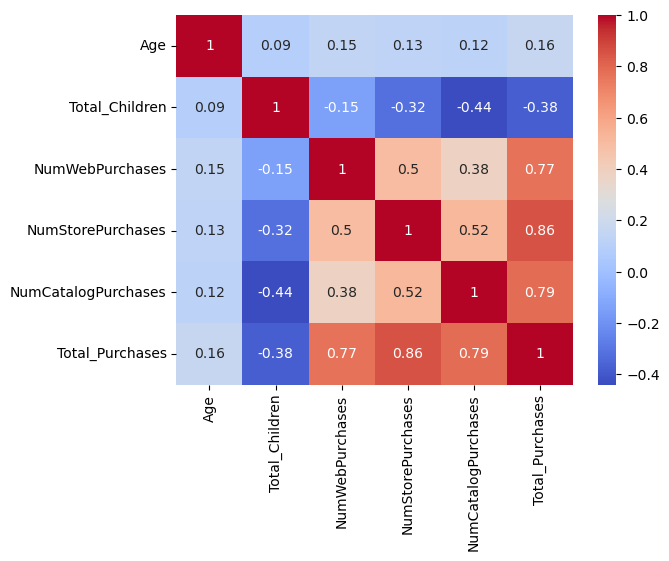

In [13]:
# Generate a heatmap to illustrate the correlation between different pairs of variables. 
# Focus on relevant variables only. The ones used in the groupby analysis and the new derived columns.
cols = [
    'Age', 'Total_Children',
    'NumWebPurchases','NumStorePurchases','NumCatalogPurchases',
    'Total_Purchases'
]

corr_matrix = df[cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

---
## 8. Test the follow Hypothesis:

1. Older individuals may not possess the same level of technological proficiency and may, therefore, lean toward traditional in-store shopping preferences. 

    - Older groups (Seniors and Elderly) show the highest store purchases (5,557 and 4,201) compared to web and catalog channels. The heatmap shows a different relationship because correlation measures linear trends at the individual level, while aggregation highlights total behavior across groups. Although older age groups have higher total store purchases, this does not indicate that all older individuals consistently prefer in-store shopping. Variability within groups and multichannel behavior weaken the correlation, making the relationship appear less pronounced in the heatmap.

2. Customers with children likely experience time constraints, making online shopping a more convenient option. 
    - Customers with 0 children have the highest catalog purchases (3,036) and strong web activity, while those with more children show declining web purchases. This suggests that customers with children are not more inclined toward online shopping, contradicting the hypothesis.

3. Sales at physical stores may face the risk of cannibalization by alternative distribution channels.
    - Store purchases remain the dominant channel (46.18%), significantly higher than web (32.58%) and catalog (21.23%). There is no evidence of declining store performance relative to other channels, indicating no clear cannibalization effect.

4. Does the United States significantly outperform the rest of the world in total purchase volumes?
    - The U.S. (1,473 purchases) significantly underperforms compared to countries like SP (13,583) and SA (4,302). This shows the U.S. does not dominate global purchase volume.

Overall Conclusion

Only the age-based shopping behavior hypothesis is supported, while the others are not supported by the data, indicating that channel usage and geography are more evenly distributed than expected.

---
## 9. Key Findings. 
Use appropriate visualization to help analyze the following:
1. Identify the top-performing products and those with the lowest revenue. 

2. Examine if there is a correlation between customers' age and the acceptance rate of the last campaign. 

3. Determine the country with the highest number of customers who accepted the last campaign. 

4. Investigate if there is a discernible pattern in the number of children at home and the total expenditure. 

5. Analyze the educational background of customers who lodged complaints in the last two years. 

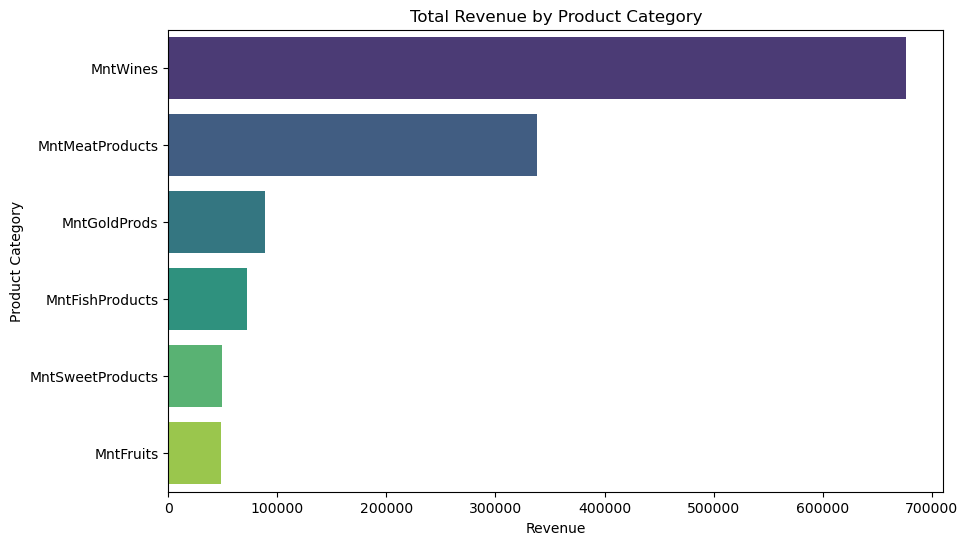

In [14]:
# 9.1 Identify the top-performing products and those with the lowest revenue. 
mnt_cols = [c for c in df.columns if c.startswith('Mnt')]
product_revenue = df[mnt_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=product_revenue.values, y=product_revenue.index, palette='viridis')
plt.title('Total Revenue by Product Category')
plt.xlabel('Revenue')
plt.ylabel('Product Category')
plt.show()

**📝 Insight:** The analysis shows that wine and meat products are the top revenue drivers, significantly outperforming other categories. In contrast, fruits and sweets generate the lowest revenue, indicating weaker customer demand. This suggests an opportunity to optimize inventory and promotions by focusing on high-performing products while reevaluating the strategy for underperforming categories.

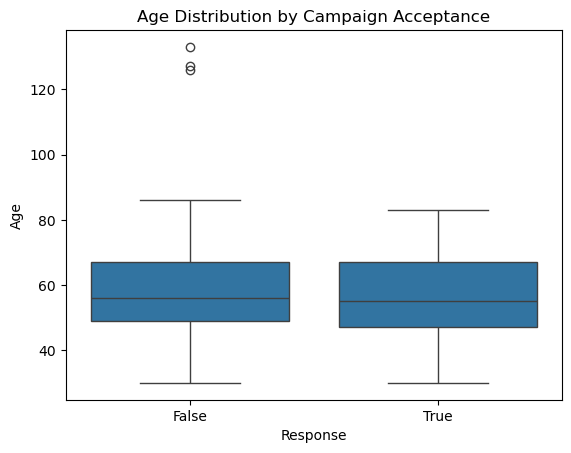

In [15]:
# 9.2. Examine if there is a correlation between customers' age and the acceptance rate of the last campaign. 
# Age vs Campaign Response (Correlation)
sns.boxplot(x='Response', y='Age', data=df)
plt.title('Age Distribution by Campaign Acceptance')
plt.show()

**📝 Insight:** The average age of customers who accepted the campaign is almost identical to those who did not. This suggests that age alone is not a strong predictor of campaign acceptance in this specific group. The campaign seems to appeal to a broad age range rather than a specific demographic pocket.

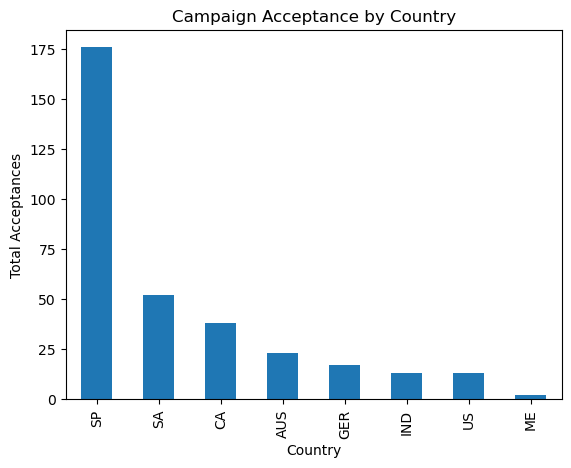

In [16]:
# 9.3. Determine the country with the highest number of customers who accepted the last campaign. 
# Country with highest acceptance
country_response = df.groupby('Country')['Response'].sum().sort_values(ascending=False)
country_response.plot(kind='bar', title='Campaign Acceptance by Country')
plt.ylabel('Total Acceptances')
plt.show()

**📝 Insight:** The results show that certain countries contribute a higher number of campaign acceptances, with one country clearly leading in total responses. This indicates that geographic factors play a role in campaign effectiveness, and marketing efforts could be further optimized by targeting high-performing regions.

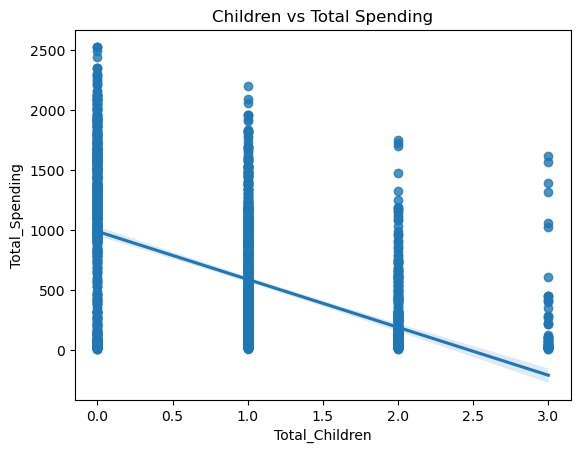

In [17]:
# 9.4. Investigate if there is a discernible pattern in the number of children at home and the total expenditure. 
# Children vs Total Expenditure
sns.regplot(x='Total_Children', y='Total_Spending', data=df)
plt.title('Children vs Total Spending')
plt.show()

**📝 Insight:** There is a clear "discernible pattern"—spending is highest for customers with no children at home. Expenditure drops significantly once there is 1 or more children at home. This highlights that "Empty Nesters" or single professionals are your most lucrative high-value segments.

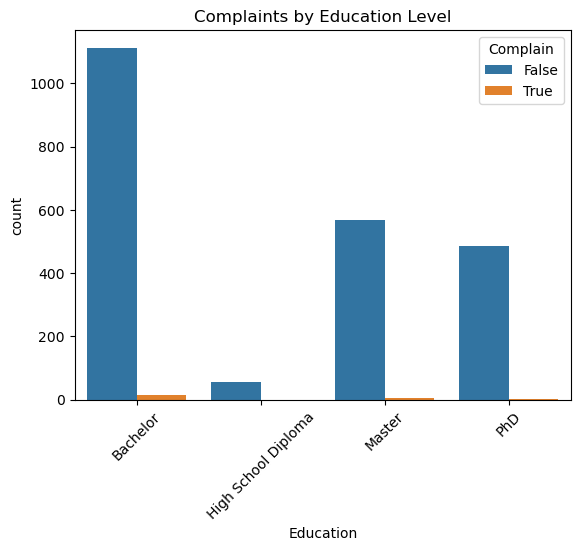

In [18]:
# 9.5. Analyze the educational background of customers who lodged complaints in the last two years. 
# Education vs Complaints
sns.countplot(x='Education', hue='Complain', data=df)
plt.title('Complaints by Education Level')
plt.xticks(rotation=45)
plt.show()

**📝 Insight:** The analysis shows that complaints are distributed across education levels, with some groups exhibiting slightly higher counts. However, no single education category overwhelmingly dominates, suggesting that customer dissatisfaction is not strongly tied to education level. This implies that service improvements should be applied broadly rather than targeting a specific segment.

---
## 10. Recommendations

> Be specific. Every recommendation should connect back to a finding above.  
> Avoid vague statements like "improve sales" — say *where*, *how*, and *why*.

| # | Finding | Recommendation | Priority |
|---|---|---|---|
| 1 | Store purchases dominate (46%) and no cannibalization observed | Invest in omnichannel strategy by enhancing in-store experience while integrating digital touchpoints (e.g., buy-online-pickup-in-store) to further increase total customer spend | High |
| 2 | Older customers (Seniors/Elderly) show higher store purchase activity | Target older segments with in-store promotions and loyalty programs, including personalized offers and senior-focused discounts to maximize high-value customer engagement | Medium |
| 3 | Customers with more children spend less and show lower online activity | Develop family-oriented promotions and value bundles, particularly online, to encourage higher spending among households with children and reduce spending constraints | Medium |


---
## 11. Conclusion

The analysis identified key factors influencing customer behavior across the four Ps of marketing. Product analysis showed that certain categories drive the majority of revenue, while others underperform and require strategic adjustment. Place and promotion insights revealed that customers engage across multiple channels, with in-store purchases leading and campaign responsiveness varying by demographic segments. Price and demographic factors, such as income, age, and household composition, influence spending patterns but are not always strong predictors of behavior on their own. Overall, customer acquisition and engagement can be improved through targeted, data-driven strategies that align product offerings, pricing, distribution channels, and promotional efforts with specific customer segments.